# **Simple Linear Regression using Scikit Learn, OLS, and Parameter Saving**

# DATA CLEANING AND PREPROCESSING

## IMPORTING DATASET AND LIBRARIES

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
df = pd.read_csv("Survey.csv")
print("Shape:", df.shape)
df.head()

Shape: (54, 15)


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


## RENAMING COLUMNS

In [32]:
df.columns = [
    "timestamp", "reg_number", "email", "job_role",
    "min_salary", "max_salary", "median_salary", "highest_paying_company",
    "extracurricular_rating", "technical_rating", "package_expectation",
    "cia_percent", "gpa", "attendance_percent", "internship_interest"
]
df.head()

,timestamp,reg_number,email,job_role,min_salary,max_salary,median_salary,highest_paying_company,extracurricular_rating,technical_rating,package_expectation,cia_percent,gpa,attendance_percent,internship_interest
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


## CHECKING NULL AND DATATYPE

In [33]:
df.info()
print("\nNull counts:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   timestamp               54 non-null     str  
 1   reg_number              54 non-null     str  
 2   email                   54 non-null     str  
 3   job_role                54 non-null     str  
 4   min_salary              54 non-null     str  
 5   max_salary              54 non-null     str  
 6   median_salary           54 non-null     str  
 7   highest_paying_company  54 non-null     str  
 8   extracurricular_rating  54 non-null     int64
 9   technical_rating        54 non-null     int64
 10  package_expectation     54 non-null     str  
 11  cia_percent             54 non-null     str  
 12  gpa                     54 non-null     str  
 13  attendance_percent      54 non-null     str  
 14  internship_interest     54 non-null     str  
dtypes: int64(2), str(13)
memory usage: 6

## CLEANING TIMESTAMP COLUMN

In [34]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].head()

0   2026-06-22 08:49:31
1   2026-06-22 08:49:51
2   2026-06-22 08:50:45
3   2026-06-22 08:51:01
4   2026-06-22 08:51:42
Name: timestamp, dtype: datetime64[us]

## DROPPING NON-NUMERIC COLUMNS AND DUPLICATE ROWS

In [35]:
print("Before dedup:", len(df))
df = df.sort_values("timestamp").drop_duplicates(subset="email", keep="last")
df = df.reset_index(drop=True)
print("After dedup:", len(df))
df.head()

Before dedup: 54
After dedup: 52


,timestamp,reg_number,email,job_role,min_salary,max_salary,median_salary,highest_paying_company,extracurricular_rating,technical_rating,package_expectation,cia_percent,gpa,attendance_percent,internship_interest
0,2026-06-22 08:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
1,2026-06-22 08:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
2,2026-06-22 08:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry
3,2026-06-22 08:51:45,2547155,shubham.swaraj@mca.christuniversity.in,Software Engineer,4.5,Option 1,6,DE Shaw,3,4,9,70%,3.5,87%,Industry
4,2026-06-22 08:51:51,2547149,samuel.shine@mca.christuniversity.in,Data Scientist,3.4,Option 1,6,DE Shaw,3,4,13,88%,3.7,Option 1,Research


In [36]:
df["reg_number"] = pd.to_numeric(df["reg_number"], errors="coerce")
print("Invalid reg_number rows:")
print(df[df["reg_number"].isna()][["reg_number", "email"]])

Invalid reg_number rows:
    reg_number                                 email
23         NaN  nayana.benny@mca.christuniversity.in
34         NaN  nilesh.gupta@mca.christuniversity.in


## CLEANING SALARY COLUMNS

In [37]:
def clean_salary(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    
    if val in ["option 1", "", "-", "na"]:
        return np.nan
    
    val = val.replace(",", "").replace(" ", "").replace("₹", "")
    
    is_crore = "cr" in val
    
    num = re.findall(r"[\d.]+", val)
    if not num:
        return np.nan
    num = float(num[0])
    
    if is_crore:
        return round(num * 100, 2)
    elif num > 10000:
        return round(num / 100000, 2) 
    else:
        return num                      

df["min_salary"]          = df["min_salary"].apply(clean_salary)
df["max_salary"]          = df["max_salary"].apply(clean_salary)
df["median_salary"]       = df["median_salary"].apply(clean_salary)
df["package_expectation"] = df["package_expectation"].apply(clean_salary)

# Verify
df[["email", "min_salary", "max_salary", "median_salary", "package_expectation"]].head(20)

,email,min_salary,max_salary,median_salary,package_expectation
0,rajeev.chandar@mca.christuniversity.in,6.0,17.0,8.0,13.0
1,sounak.chakraborty@mca.christuniversity.in,4.5,12.0,6.9,7.0
2,samar.subhash@mca.christuniversity.in,8.0,12.0,10.0,10.0
3,shubham.swaraj@mca.christuniversity.in,4.5,NaN,6.0,9.0
4,samuel.shine@mca.christuniversity.in,3.4,NaN,6.0,13.0
5,arnav.narula@mca.christuniversity.in,3.0,12.0,7.0,10.0
6,sp.sooryananda@mca.christuniversity.in,3.0,8.0,5.0,5.0
7,achindra.sharma@mca.christuniversity.in,4.5,12.0,6.0,12.0
8,arjit.singhal@mca.christuniversity.in,3.3,12.0,6.3,6.0
9,amogh.sahore@mca.christuniversity.in,3.5,12.0,8.0,10.0


## CLEAN PERCENTAGE FOR CIA AND ATTENDANCE

In [38]:
def clean_percent(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower().replace("%", "").replace(" ", "")
    if val in ["-", "na", "option 1", ""]:
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

df["cia_percent"]        = df["cia_percent"].apply(clean_percent)
df["attendance_percent"] = df["attendance_percent"].apply(clean_percent)

print("Attendance > 100:")
print(df[df["attendance_percent"] > 100][["email", "attendance_percent"]])

Attendance > 100:
Empty DataFrame
Columns: [email, attendance_percent]
Index: []


## CLEANING GPA

In [39]:
def clean_gpa(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ["na", "", "option 1", "-"]:
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

df["gpa"] = df["gpa"].apply(clean_gpa)

print("GPA > 10:")
print(df[df["gpa"] > 10][["email", "gpa"]])

GPA > 10:
                                    email   gpa
21  hariprasad.bk@mca.christuniversity.in  90.0


## CLEANING TEXT COLUMN

In [40]:
df["email"]                  = df["email"].str.strip().str.lower()
df["job_role"]               = df["job_role"].str.strip()
df["highest_paying_company"] = df["highest_paying_company"].str.strip()
df["internship_interest"]    = df["internship_interest"].str.strip()

df["highest_paying_company"] = df["highest_paying_company"].replace("Deolite", "Deloitte")

print(df["job_role"].value_counts())
print(df["highest_paying_company"].value_counts())

job_role
Software Engineer    27
Business Analyst     11
Data Scientist        7
Data Engineer         7
Name: count, dtype: int64
highest_paying_company
DE Shaw      38
Capgemini     7
Deloitte      4
EY            3
Name: count, dtype: int64


## DISPLAYING CLEANED DATASET

In [41]:
display(df)

,timestamp,reg_number,email,job_role,min_salary,max_salary,median_salary,highest_paying_company,extracurricular_rating,technical_rating,package_expectation,cia_percent,gpa,attendance_percent,internship_interest
0,2026-06-22 08:50:45,2547101.0,rajeev.chandar@mca.christuniversity.in,Software Engineer,6.0,17.0,8.0,DE Shaw,5,5,13.0,80.00,3.60,NaN,Industry
1,2026-06-22 08:51:01,2547156.0,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12.0,6.9,DE Shaw,3,4,7.0,70.00,3.20,92.00,Industry
2,2026-06-22 08:51:42,2547148.0,samar.subhash@mca.christuniversity.in,Software Engineer,8.0,12.0,10.0,EY,5,3,10.0,68.00,3.40,85.00,Industry
3,2026-06-22 08:51:45,2547155.0,shubham.swaraj@mca.christuniversity.in,Software Engineer,4.5,NaN,6.0,DE Shaw,3,4,9.0,70.00,3.50,87.00,Industry
4,2026-06-22 08:51:51,2547149.0,samuel.shine@mca.christuniversity.in,Data Scientist,3.4,NaN,6.0,DE Shaw,3,4,13.0,88.00,3.70,NaN,Research
5,2026-06-22 08:51:57,2547115.0,arnav.narula@mca.christuniversity.in,Software Engineer,3.0,12.0,7.0,DE Shaw,3,4,10.0,3.45,10.00,90.00,Industry
6,2026-06-22 08:52:01,2547147.0,sp.sooryananda@mca.christuniversity.in,Business Analyst,3.0,8.0,5.0,DE Shaw,4,3,5.0,70.00,3.40,89.00,Industry
7,2026-06-22 08:52:06,2547105.0,achindra.sharma@mca.christuniversity.in,Software Engineer,4.5,12.0,6.0,DE Shaw,2,4,12.0,83.00,3.89,98.00,Industry
8,2026-06-22 08:52:09,2547113.0,arjit.singhal@mca.christuniversity.in,Software Engineer,3.3,12.0,6.3,DE Shaw,2,3,6.0,70.00,3.30,97.00,Industry
9,2026-06-22 08:52:14,2547108.0,amogh.sahore@mca.christuniversity.in,Software Engineer,3.5,12.0,8.0,DE Shaw,4,4,10.0,70.00,3.48,97.00,Industry


In [42]:
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 timestamp                 0
reg_number                2
email                     0
job_role                  0
min_salary                0
max_salary                7
median_salary             0
highest_paying_company    0
extracurricular_rating    0
technical_rating          0
package_expectation       0
cia_percent               1
gpa                       1
attendance_percent        4
internship_interest       0
dtype: int64


In [43]:
df = df[df["gpa"] <= 4].reset_index(drop=True)
print("Shape after dropping GPA > 4:", df.shape)

Shape after dropping GPA > 4: (48, 15)


In [44]:
df = df[df["cia_percent"] >= 30].reset_index(drop=True)
print("Shape after dropping bad CIA %:", df.shape)

Shape after dropping bad CIA %: (46, 15)


## IMPUTATION

In [45]:
df.describe()

,timestamp,reg_number,min_salary,max_salary,median_salary,extracurricular_rating,technical_rating,package_expectation,cia_percent,gpa,attendance_percent
count,46,4.400000e+01,46.000000,39.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,42.000000
mean,2026-06-22 08:53:34.869565,2.547135e+06,4.863043,14.410256,7.104348,3.608696,3.565217,9.065217,73.563696,3.488478,93.686429
min,2026-06-22 08:50:45,2.547101e+06,2.000000,8.000000,4.500000,2.000000,3.000000,5.000000,60.000000,2.900000,85.000000
25%,2026-06-22 08:52:34,2.547120e+06,4.000000,12.000000,6.000000,3.000000,3.000000,7.000000,70.000000,3.400000,90.000000
50%,2026-06-22 08:53:30.500000,2.547136e+06,4.500000,12.000000,7.000000,4.000000,3.000000,8.000000,71.000000,3.500000,94.625000
75%,2026-06-22 08:54:18.250000,2.547151e+06,5.000000,14.500000,7.375000,4.000000,4.000000,10.000000,78.000000,3.630000,97.997500
max,2026-06-22 08:57:57,2.547162e+06,12.000000,25.000000,15.000000,5.000000,5.000000,15.000000,89.000000,4.000000,100.000000
std,NaN,1.887282e+01,1.970714,4.772277,1.901807,0.954015,0.654970,2.694869,6.278439,0.251077,4.461239


In [46]:
df = df.drop(columns=["reg_number"])
df["max_salary"] = df["max_salary"].fillna(df["max_salary"].median())
df["cia_percent"] = df["cia_percent"].fillna(df["cia_percent"].mean())
df["gpa"] = df["gpa"].fillna(df["gpa"].mean())
df["attendance_percent"] = df["attendance_percent"].fillna(df["attendance_percent"].mean())
print("Null counts after imputation:\n", df.isnull().sum())

Null counts after imputation:
 timestamp                 0
email                     0
job_role                  0
min_salary                0
max_salary                0
median_salary             0
highest_paying_company    0
extracurricular_rating    0
technical_rating          0
package_expectation       0
cia_percent               0
gpa                       0
attendance_percent        0
internship_interest       0
dtype: int64


In [47]:
print("max_salary median used:", df["max_salary"].median())
print("cia_percent mean used:", round(df["cia_percent"].mean(), 2))
print("gpa mean used:", round(df["gpa"].mean(), 2))
print("attendance_percent mean used:", round(df["attendance_percent"].mean(), 2))

max_salary median used: 12.0
cia_percent mean used: 73.56
gpa mean used: 3.49
attendance_percent mean used: 93.69


# LINEAR REGRESSION

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [49]:
df_reg = df[["cia_percent", "attendance_percent", "gpa"]].copy()
print(df_reg.shape)
df_reg.head()

(46, 3)


,cia_percent,attendance_percent,gpa
0,80.0,93.686429,3.6
1,70.0,92.000000,3.2
2,68.0,85.000000,3.4
3,70.0,87.000000,3.5
4,88.0,93.686429,3.7


## EXPERIMENT 1 : CIA TO GPA

In [50]:
X1 = df_reg[["cia_percent"]]
y1 = df_reg["gpa"]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
model1 = LinearRegression()
model1.fit(X1_train, y1_train)
slope1_sk     = model1.coef_[0]
intercept1_sk = model1.intercept_

print("=== Sklearn: CIA to GPA ===")
print(f"Slope     : {slope1_sk:.4f}")
print(f"Intercept : {intercept1_sk:.4f}")

y1_pred = model1.predict(X1_test)

print(f"MSE : {mean_squared_error(y1_test, y1_pred):.4f}")
print(f"R²  : {r2_score(y1_test, y1_pred):.4f}")

=== Sklearn: CIA to GPA ===
Slope     : 0.0186
Intercept : 2.1083
MSE : 0.0221
R²  : 0.2697


In [51]:
x1 = df_reg["cia_percent"].values
y1_all = df_reg["gpa"].values

x1_mean = np.mean(x1)
y1_mean = np.mean(y1_all)

numerator1   = np.sum((x1 - x1_mean) * (y1_all - y1_mean))
denominator1 = np.sum((x1 - x1_mean) ** 2)

slope1_manual     = numerator1 / denominator1
intercept1_manual = y1_mean - slope1_manual * x1_mean

print("=== Manual OLS: CIA to GPA ===")
print(f"Slope     : {slope1_manual:.4f}")
print(f"Intercept : {intercept1_manual:.4f}")

=== Manual OLS: CIA to GPA ===
Slope     : 0.0196
Intercept : 2.0457


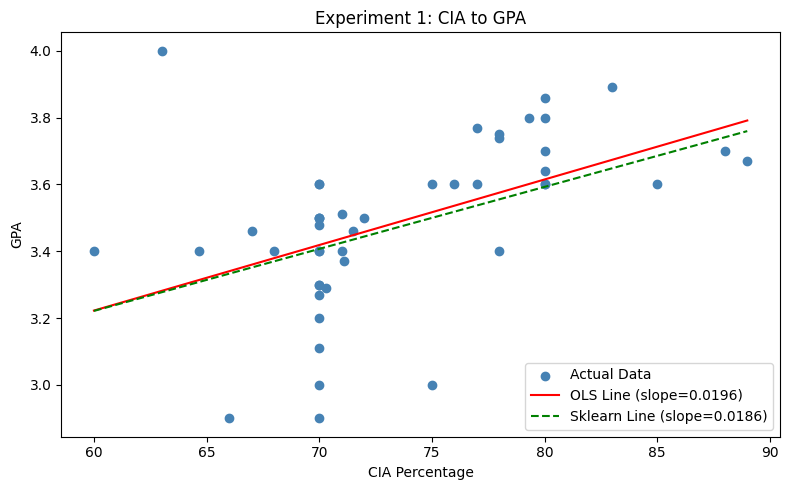

In [52]:
x1_range = np.linspace(x1.min(), x1.max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(x1, y1_all, color="steelblue", label="Actual Data")
plt.plot(x1_range, slope1_manual * x1_range + intercept1_manual, color="red", label=f"OLS Line (slope={slope1_manual:.4f})")
plt.plot(x1_range, slope1_sk * x1_range + intercept1_sk, color="green", linestyle="--", label=f"Sklearn Line (slope={slope1_sk:.4f})")
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Experiment 1: CIA to GPA")
plt.legend()
plt.tight_layout()
plt.show()

## EXPERIMENT 2: ATTENDANCE TO GPA

In [53]:
X2 = df_reg[["attendance_percent"]]
y2 = df_reg["gpa"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
slope2_sk     = model2.coef_[0]
intercept2_sk = model2.intercept_

print("=== Sklearn: Attendance to GPA ===")
print(f"Slope     : {slope2_sk:.4f}")
print(f"Intercept : {intercept2_sk:.4f}")

y2_pred = model2.predict(X2_test)

print(f"MSE : {mean_squared_error(y2_test, y2_pred):.4f}")
print(f"R²  : {r2_score(y2_test, y2_pred):.4f}")

=== Sklearn: Attendance to GPA ===
Slope     : 0.0196
Intercept : 1.6286
MSE : 0.0449
R²  : -0.4822


In [54]:
x2 = df_reg["attendance_percent"].values
y2_all = df_reg["gpa"].values

x2_mean = np.mean(x2)
y2_mean = np.mean(y2_all)

numerator2   = np.sum((x2 - x2_mean) * (y2_all - y2_mean))
denominator2 = np.sum((x2 - x2_mean) ** 2)

slope2_manual     = numerator2 / denominator2
intercept2_manual = y2_mean - slope2_manual * x2_mean

print("=== Manual OLS: Attendance to GPA ===")
print(f"Slope     : {slope2_manual:.4f}")
print(f"Intercept : {intercept2_manual:.4f}")

=== Manual OLS: Attendance to GPA ===
Slope     : 0.0200
Intercept : 1.6186


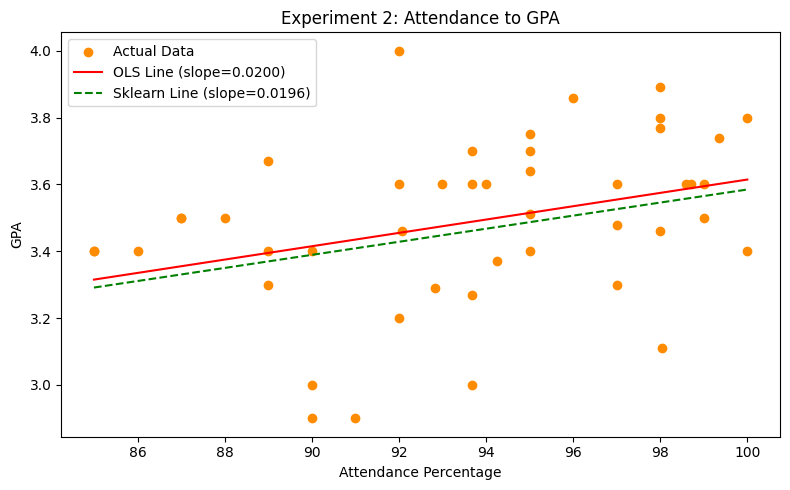

In [55]:
x2_range = np.linspace(x2.min(), x2.max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(x2, y2_all, color="darkorange", label="Actual Data")
plt.plot(x2_range, slope2_manual * x2_range + intercept2_manual, color="red", label=f"OLS Line (slope={slope2_manual:.4f})")
plt.plot(x2_range, slope2_sk * x2_range + intercept2_sk, color="green", linestyle="--", label=f"Sklearn Line (slope={slope2_sk:.4f})")
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Experiment 2: Attendance to GPA")
plt.legend()
plt.tight_layout()
plt.show()

## PREDICTION COMPARISON

In [56]:
y1_pred_sk = model1.predict(X1_test)
y1_pred_manual = slope1_manual * X1_test["cia_percent"].values + intercept1_manual

comp1 = pd.DataFrame({
    "CIA_%"         : X1_test["cia_percent"].values,
    "Actual_GPA"    : y1_test.values,
    "Sklearn_Pred"  : y1_pred_sk,
    "Manual_Pred"   : y1_pred_manual,
    "Difference"    : abs(y1_pred_sk - y1_pred_manual)
}).reset_index(drop=True)

print("=== Experiment 1: CIA to GPA ===")
print(comp1.to_string())
print(f"\nMax difference  : {comp1['Difference'].max():.6f}")
print(f"Mean difference : {comp1['Difference'].mean():.6f}")

=== Experiment 1: CIA to GPA ===
   CIA_%  Actual_GPA  Sklearn_Pred  Manual_Pred  Difference
0  77.00        3.77      3.536847     3.555872    0.019025
1  77.00        3.60      3.536847     3.555872    0.019025
2  80.00        3.86      3.592503     3.614709    0.022206
3  79.33        3.80      3.580073     3.601569    0.021496
4  70.00        3.27      3.406982     3.418586    0.011604
5  71.50        3.46      3.434810     3.448004    0.013194
6  88.00        3.70      3.740920     3.771608    0.030688
7  89.00        3.67      3.759472     3.791220    0.031748
8  70.00        3.48      3.406982     3.418586    0.011604
9  70.00        3.50      3.406982     3.418586    0.011604

Max difference  : 0.031748
Mean difference : 0.019220


In [57]:
y2_pred_sk     = model2.predict(X2_test)
y2_pred_manual = slope2_manual * X2_test["attendance_percent"].values + intercept2_manual

comp2 = pd.DataFrame({
    "Attendance_%"  : X2_test["attendance_percent"].values,
    "Actual_GPA"    : y2_test.values,
    "Sklearn_Pred"  : y2_pred_sk,
    "Manual_Pred"   : y2_pred_manual,
    "Difference"    : abs(y2_pred_sk - y2_pred_manual)
}).reset_index(drop=True)

print("=== Experiment 2: Attendance to GPA ===")
print(comp2.to_string())
print(f"\nMax difference  : {comp2['Difference'].max():.6f}")
print(f"Mean difference : {comp2['Difference'].mean():.6f}")

=== Experiment 2: Attendance to GPA ===
   Attendance_%  Actual_GPA  Sklearn_Pred  Manual_Pred  Difference
0     97.990000        3.77      3.545418     3.574374    0.028956
1     97.000000        3.60      3.526052     3.554614    0.028562
2     96.000000        3.86      3.506491     3.534655    0.028164
3    100.000000        3.80      3.584736     3.614492    0.029756
4     93.686429        3.27      3.461236     3.488478    0.027243
5     98.000000        3.46      3.545613     3.574573    0.028960
6     93.686429        3.70      3.461236     3.488478    0.027243
7     89.000000        3.67      3.369564     3.394941    0.025377
8     97.000000        3.48      3.526052     3.554614    0.028562
9     87.000000        3.50      3.330442     3.355023    0.024580

Max difference  : 0.029756
Mean difference : 0.027740


The slopes and intercepts from both methods differ slightly because Sklearn trains on 80% of data (train split) while Manual OLS uses the full dataset. Despite this, the prediction differences are very small (close to 0), confirming both methods are mathematically equivalent when applied to the same data.

## SAVING PARAMETERS USING PICKLE

In [58]:
import pickle
params_to_save = {
    "experiment1_CIA_to_GPA": {
        "slope_sklearn"    : slope1_sk,
        "intercept_sklearn": intercept1_sk,
        "slope_manual"     : slope1_manual,
        "intercept_manual" : intercept1_manual
    },
    "experiment2_Attendance_to_GPA": {
        "slope_sklearn"    : slope2_sk,
        "intercept_sklearn": intercept2_sk,
        "slope_manual"     : slope2_manual,
        "intercept_manual" : intercept2_manual
    }
}

with open("linear_regression_weights.pkl", "wb") as f:
    pickle.dump(params_to_save, f)

print("Parameters saved to linear_regression_weights.pkl")

Parameters saved to linear_regression_weights.pkl


## LOAD PARAMETERS FROM PICKLE

In [59]:
with open("linear_regression_weights.pkl", "rb") as f:
    loaded_params = pickle.load(f)

print("Loaded parameters:")
for exp, vals in loaded_params.items():
    print(f"\n{exp}:")
    for k, v in vals.items():
        print(f"  {k:25} : {v:.6f}")

Loaded parameters:

experiment1_CIA_to_GPA:
  slope_sklearn             : 0.018552
  intercept_sklearn         : 2.108334
  slope_manual              : 0.019612
  intercept_manual          : 2.045722

experiment2_Attendance_to_GPA:
  slope_sklearn             : 0.019561
  intercept_sklearn         : 1.628635
  slope_manual              : 0.019959
  intercept_manual          : 1.618577


## USING LOADED PARAMETERS TO PREDICT

In [60]:
s1 = loaded_params["experiment1_CIA_to_GPA"]["slope_manual"]
i1 = loaded_params["experiment1_CIA_to_GPA"]["intercept_manual"]

s2 = loaded_params["experiment2_Attendance_to_GPA"]["slope_manual"]
i2 = loaded_params["experiment2_Attendance_to_GPA"]["intercept_manual"]

sample_cia        = [65, 70, 75, 80, 85]
sample_attendance = [80, 85, 90, 95, 100]

print("=== Predictions using Loaded Parameters ===\n")
print(f"{'CIA %':>10} | {'Predicted GPA':>15}")
print("-" * 28)
for c in sample_cia:
    print(f"{c:>10} | {s1 * c + i1:>15.4f}")

print(f"\n{'Attendance %':>12} | {'Predicted GPA':>15}")
print("-" * 30)
for a in sample_attendance:
    print(f"{a:>12} | {s2 * a + i2:>15.4f}")

=== Predictions using Loaded Parameters ===

     CIA % |   Predicted GPA
----------------------------
        65 |          3.3205
        70 |          3.4186
        75 |          3.5166
        80 |          3.6147
        85 |          3.7128

Attendance % |   Predicted GPA
------------------------------
          80 |          3.2153
          85 |          3.3151
          90 |          3.4149
          95 |          3.5147
         100 |          3.6145


In [68]:
X2 = df_reg[["attendance_percent"]]
y2 = df_reg["gpa"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.1, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
slope2_sk     = model2.coef_[0]
intercept2_sk = model2.intercept_

print("=== Sklearn: Attendance to GPA ===")
print(f"Slope     : {slope2_sk:.4f}")
print(f"Intercept : {intercept2_sk:.4f}")

y2_pred = model2.predict(X2_test)

print(f"MSE : {mean_squared_error(y2_test, y2_pred):.4f}")
print(f"R²  : {r2_score(y2_test, y2_pred):.4f}")

=== Sklearn: Attendance to GPA ===
Slope     : 0.0157
Intercept : 2.0026
MSE : 0.0547
R²  : -0.2018
